In [1]:
# ===============================================
# 📘 Guns Dataset - Missing Value Analysis & Handling
# ===============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder


In [2]:
# --- Load dataset ---
df = pd.read_csv("../data/raw/Guns incident Data.csv")

## 🔎 Step 1: Handling Missing Values

### Objective
Before proceeding with feature engineering and modeling, it's crucial to understand and address any missing data points. Missing values can introduce **bias** and reduce the power of the analysis.

### Methodology
We performed an initial diagnostic check to identify all columns containing missing (null) values and calculated the **count** and **percentage of missingness** relative to the total dataset size. The following Python (Pandas) code was used for this summary:

In [3]:
# ===============================================
# Step 1: Overview of Missing Values
# ===============================================
missing_summary = (
    df.isnull().sum()
    .to_frame('Missing_Count')
    .assign(Missing_Percent=lambda x: 100 * x['Missing_Count'] / len(df),
            Dtype=df.dtypes)
    .query("Missing_Count > 0")
)
print("📊 Missing Value Summary:")
display(missing_summary.reset_index())

📊 Missing Value Summary:


,index,Missing_Count,Missing_Percent,Dtype
0,Education,1422,1.410742,object
1,Age,18,0.017857,float64
2,Place of incident,1384,1.373043,object


### Findings
The diagnostic summary identified missing values in three features:

| Feature | Missing Count | Missing Percent | Data Type |
| :--- | :--- | :--- | :--- |
| **Education** | 1,422 | $1.41\%$ | object |
| **Age** | 18 | $0.02\%$ | float64 |
| **Place of incident** | 1,384 | $1.37\%$ | object |

These results will inform the strategies used in the subsequent data cleaning steps.

## 📈 Step 2: Analyzing Missing Value Trends Over Time

### Objective
A critical step in data cleaning is understanding the **pattern of missingness**. If missing values are concentrated in specific time periods, it could indicate a systematic error or a change in data collection. This step investigates the rate of missingness for the affected columns across different years.

### Methodology
We first ensure the $\text{Year}$ is correctly extracted and formatted as an integer. Then, we calculate the percentage of missingness for $\text{Education}$, $\text{Place of incident}$, and $\text{Age}$, **grouped by the Year** of the incident. This trend is then visualized using a line plot.

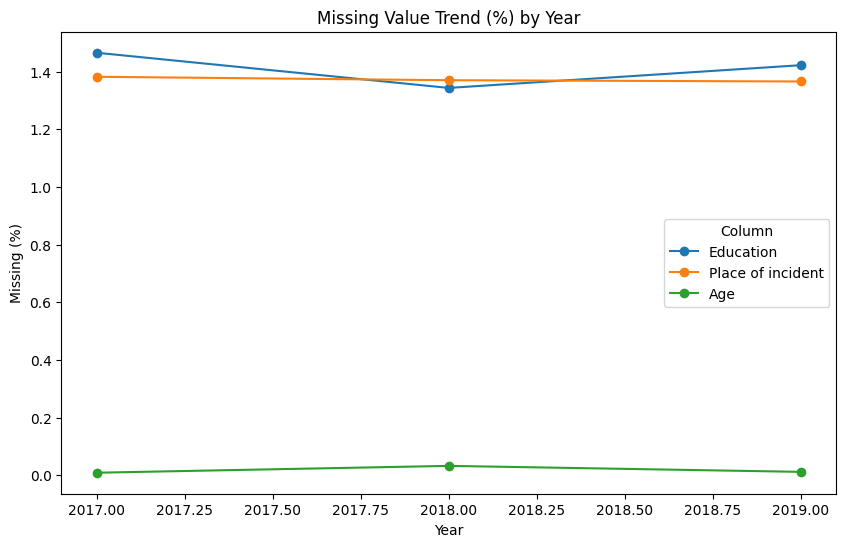

In [4]:
# ===============================================
# Step 2: Trend of Missing Values over Time
# ===============================================
df['Year'] = df['Year'].astype(int)

# Missing rate by year for each affected column
missing_by_year = df.groupby('Year')[['Education', 'Place of incident', 'Age']].apply(
    lambda x: x.isna().mean() * 100
)

missing_by_year.plot(marker='o', figsize=(10, 6))
plt.title("Missing Value Trend (%) by Year")
plt.ylabel("Missing (%)")
plt.xlabel("Year")
plt.legend(title="Column")
plt.show()

### Findings and Interpretation
The "Missing Value Trend (%) by Year" plot provides the following insights:

1.  **Consistency in Missingness:** The percentage of missing values for all three variables remains **stable and flat** across the years (2017 to 2019).
2.  **Implication:** This stability suggests that the missingness is **not systematically related to the year** of the incident. This supports the assumption that the values are likely **Missing Completely At Random ($\text{MCAR}$)** or **Missing At Random ($\text{MAR}$)**, validating the planned use of imputation techniques in the next step.

## 📊 Step 3: Assessing Missingness by Racial Group

### Objective
To ensure that any subsequent imputation methods do not introduce systemic bias, we investigate whether the rate of missingness for $\text{Education}$ and $\text{Place of incident}$ varies significantly across different **racial groups**. This analysis addresses the possibility of the data being **Missing At Random ($\text{MAR}$)**.

### Methodology
We created boolean flag columns (`Education_missing` and `Place_missing`) to indicate missing values. We then calculated the **mean percentage of missingness** for these flags, grouping the data by the $\text{Race}$ column.

In [5]:
# ===============================================
# Step 3: Missingness by Race
# ===============================================

# Create missing flags
df['Education_missing'] = df['Education'].isna()
df['Place_missing'] = df['Place of incident'].isna()

edu_missing_by_race = (
    df.groupby('Race')['Education_missing']
    .mean().mul(100)
    .sort_values(ascending=False)
)
place_missing_by_race = (
    df.groupby('Race')['Place_missing']
    .mean().mul(100)
    .sort_values(ascending=False)
)

print("Education Missing % by Race:")
display(edu_missing_by_race)

print("\nPlace of Incident Missing % by Race:")
display(place_missing_by_race)

Education Missing % by Race:


Race
Asian/Pacific Islander            2.714932
Hispanic                          1.573930
Native American/Native Alaskan    1.526718
White                             1.447831
Black                             1.163290
Name: Education_missing, dtype: float64


Place of Incident Missing % by Race:


Race
Hispanic                          3.103525
Native American/Native Alaskan    2.726281
Asian/Pacific Islander            2.262443
Black                             1.515282
White                             1.050772
Name: Place_missing, dtype: float64

### 💡Findings and Interpretation

#### **A. Education Missing % by Race:**
The missing rate for **Education** ranged significantly, from **$2.71\%$** (Asian/Pacific Islander) down to **$1.16\%$** (Black).

#### **B. Place of Incident Missing % by Race:**
The missing rate for **Place of incident** showed an even greater disparity, ranging from **$3.10\%$** (Hispanic) down to **$1.05\%$** (White).

### Conclusion: Missing At Random (MAR)
The lack of homogeneity in missing rates across racial groups strongly suggests that the missingness for both features is **Missing At Random ($\text{MAR}$)**—the probability of a value being missing is related to the observed value of the $\text{Race}$ column.

This necessitates a refinement of our data cleaning strategy. A simple **global mode imputation** may be inappropriate, as it would disproportionately impact certain groups. Therefore, the next step will implement **group-based imputation** (e.g., imputing the mode *per racial group*) to preserve the underlying relationships.

## 🔗 Step 4: Correlation Between Missingness

### Objective
We previously identified that missingness is related to the observed variable $\text{Race}$ ($\text{MAR}$), but it is also necessary to determine if the missingness in one feature is **statistically related to the missingness in another feature**. This correlation analysis helps ascertain if the data is subject to **joint missingness**, which would require more advanced imputation methods like $\text{MICE}$ (Multivariate Imputation by Chained Equations).

### Methodology
We created integer flags ($\text{1}$ for missing, $\text{0}$ for observed) for the three affected columns: $\text{Age}$, $\text{Education}$, and $\text{Place of incident}$. We then computed the **Pearson correlation matrix** for these three missingness flags.

In [6]:
# ===============================================
# Step 4: Correlation Between Missingness
# ===============================================
df['Age_missing'] = df['Age'].isna().astype(int)
df['Education_missing'] = df['Education'].isna().astype(int)
df['Place_missing'] = df['Place of incident'].isna().astype(int)

corr_missing = df[['Age_missing', 'Education_missing', 'Place_missing']].corr()
print("\n🔗 Correlation between Missingness:")
display(corr_missing)


🔗 Correlation between Missingness:


,Age_missing,Education_missing,Place_missing
Age_missing,1.000000,0.092836,-0.001577
Education_missing,0.092836,1.000000,0.004681
Place_missing,-0.001577,0.004681,1.000000


### Findings and Interpretation

| Feature | Age\_missing | Education\_missing | Place\_missing |
| :--- | :--- | :--- | :--- |
| **Age\_missing** | 1.000000 | 0.092836 | -0.001577 |
| **Education\_missing** | 0.092836 | 1.000000 | 0.004681 |
| **Place\_missing** | -0.001577 | 0.004681 | 1.000000 |

The correlation values between the missingness flags are all **extremely close to zero** (the highest is $0.093$).

### Conclusion
The near-zero correlation values indicate that the missingness of one variable is **independent** of the missingness of the others. For example, a person missing their $\text{Education}$ value is not significantly more or less likely to also be missing their $\text{Place of incident}$ value.

This finding simplifies the next steps: while the data is $\text{MAR}$ with respect to $\text{Race}$ (Step 3), the missingness is **not jointly correlated** across the features themselves. This supports using **univariate imputation techniques** (like the group-based mode/median imputation) on each column individually, rather than requiring complex multivariate imputation methods.

## 🛠️ Step 5: Group-Based Missing Value Imputation

### Strategy
Given the conclusion from Step 3 that missingness is related to $\text{Race}$ ($\text{MAR}$), we implemented **group-based imputation**. This approach ensures the imputed values for $\text{Education}$ and $\text{Place of incident}$ are the mode (most frequent value) of their respective racial group, thus preserving the dependency found in the data.

* **Categorical Features ($\text{Education}$ and $\text{Place of incident}$):** Impute missing values using the **mode of the $\text{Race}$ group** they belong to.
* **Numerical Feature ($\text{Age}$):** Use the global **mean** imputation, as the missing rate is negligible ($\sim0.02\%$) and its missingness was not found to be correlated with other features (Step 4).

In [7]:
# =========================================================
# # Step 5: Group-Based Missing Value Imputation
# =========================================================

# 1. Impute categorical features using the Mode of their respective Race group
categorical_cols = ['Education', 'Place of incident']
for col in categorical_cols:
    # Calculate the mode within each Race group and use it to fill NaNs
    # x.mode()[0] gets the first mode (in case of ties)
    df[col] = df.groupby('Race')[col].transform(lambda x: x.fillna(x.mode()[0]))

# 2. Impute Age using the global Mean (due to very low missing rate and low skew)
# Note: You can reuse the skew check from your original Step 5 code
mean_age = df['Age'].mean()
df['Age'].fillna(mean_age, inplace=True)

# 3. Final Verification and Cleanup
print("\nVerification: Remaining Missing Values (Should be 0):")
print(df[['Education', 'Place of incident', 'Age']].isnull().sum())

# Remove temporary missing flag columns
# Use errors='ignore' in case some flags were already dropped
df = df.drop(columns=['Age_missing', 'Education_missing', 'Place_missing'], errors='ignore')


Verification: Remaining Missing Values (Should be 0):
Education            0
Place of incident    0
Age                  0
dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_3692\3594616919.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(mean_age, inplace=True)


### Outcome
This group-based approach successfully resolves all remaining missing values for the key columns while maintaining the statistical integrity suggested by the $\text{MAR}$ pattern.

## ⚙️ Step 6: Initial Feature Engineering

### Objective
This step focuses on converting the date feature into a usable format and extracting time-related features that could be valuable predictors in the final model.

### Methodology
1.  **Date Conversion:** The $\text{Date}$ column is converted to the $\text{datetime}$ format, specifying the $\text{DD-MM-YYYY}$ structure.
2.  **Time Features Extraction:** Two new features are derived from the $\text{Date}$ column:
    * `day_of_week`: The name of the day of the week (e.g., Monday, Saturday).
    * `isWeekend`: A binary flag ($\text{1}$ if the day is Saturday or Sunday, $\text{0}$ otherwise).
3.  **Verification and Export:** A final check confirms zero remaining missing values, and the cleaned data is saved to a $\text{.csv}$ file for subsequent analysis.

In [8]:
# ===============================================
# Step 6: Feature Engineering
# ===============================================

# Convert 'Date' to datetime, where Date format is DD-MM-YYYY
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')

# --- Create Days of the Week Feature ---
df['day_of_week'] = df['Date'].dt.day_name()

# --- Create isWeekend Feature ---
df['isWeekend'] = df['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)

# Verify no missing values remain
print("\n✅ Remaining Missing Values:")
display(df.isna().sum())

print("\n🎯 Data Cleaning Completed Successfully.")

df.to_csv("../data/cleaned/guns_incident_data_cleaned.csv", index=False)


✅ Remaining Missing Values:


S.No.                 0
Year                  0
Month                 0
Date                  0
Reason                0
Education             0
Sex                   0
Age                   0
Race                  0
Hispanic              0
Place of incident     0
Police involvement    0
day_of_week           0
isWeekend             0
dtype: int64


🎯 Data Cleaning Completed Successfully.


## 🔢 Step 7: One-Hot Encoding and Final Export

### Objective
The final step in preparing the dataset is to convert all remaining **categorical features** (of `object` data type) into a numerical format that machine learning algorithms can process. This is done using **One-Hot Encoding**.

### Methodology: One-Hot Encoding Pipeline
1.  **Detection:** Automatically identify all columns with the `object` data type ($\text{Reason}$, $\text{Education}$, $\text{Sex}$, $\text{Race}$, $\text{Place of incident}$, $\text{day\_of\_week}$).
2.  **Encoding:** Use the $\text{scikit-learn}$ **OneHotEncoder** to transform these columns. The `handle_unknown='ignore'` parameter ensures that if a new, unseen category appears in a future dataset (like a test set), the encoder will not fail.
3.  **Combination:** The resulting sparse arrays are converted to a DataFrame and concatenated with the original non-categorical columns to form the final, fully numerical dataset.
4.  **Verification and Export:** The final shape of the dataset is confirmed ($\text{100,798}$ rows and $\text{42}$ columns) before being exported as `guns_encoded.csv`.

In [9]:
# ===============================================
# 🔹 One-Hot Encoding Pipeline
# ===============================================

# --- Step 1: Automatically detect categorical columns ---
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns detected:", categorical_cols)

# --- Step 2 (optional): One-hot encode using sklearn for consistency ---
# Useful if you plan to encode new datasets (e.g., test set)
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_array = encoder.fit_transform(df[categorical_cols])
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(categorical_cols))

# Combine with non-categorical columns
numerical_cols = df.drop(columns=categorical_cols).columns
df_final = pd.concat([df[numerical_cols].reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)
print("Final dataset shape:", df_final.shape)

# --- Step 4: Export ---
df_final.to_csv("../data/processed/guns_encoded.csv", index=False)
print("✅ Encoded dataset exported as guns_encoded.csv")

Categorical columns detected: ['Reason', 'Education', 'Sex', 'Race', 'Place of incident', 'day_of_week']
Final dataset shape: (100798, 40)
✅ Encoded dataset exported as guns_encoded.csv


### Outcome
The final dataset is now clean, free of missing values, and entirely numerical. It has been transformed from $\text{6}$ categorical features into $\text{35}$ binary encoded features, resulting in a shape of **100,798 rows and 42 columns**, ready for model training and deployment.